In [1]:
import os
import re

import numpy as np
import pandas as pd

In [2]:
def chemical_formula_sort(formulas):
    def get_sort_key(formula):
        counts = [int(n) if n else 1 for _, n in re.findall(r'([A-Z])(\d*)', formula)]

        total_atoms = sum(counts)

        distribution = [-c for c in sorted(counts, reverse=True)]
        
        return (total_atoms, distribution)

    return sorted(formulas, key=get_sort_key)

In [3]:
def format_formula_for_matplotlib(formula):
    """
    Converts a chemical formula string like 'A3B2C' into a 
    Matplotlib-renderable LaTeX string like '$A_{3}B_{2}C$'.
    """
    # Find all letter groups followed by optional number groups
    parts = re.findall(r'([A-Z]+)(\d*)', formula)
    
    # Build the formatted string
    latex_string = ""
    for letter, number in parts:
        latex_string += letter
        if number:
            # If a number exists, wrap it in '_{...}' for subscript
            latex_string += f'_{{{number}}}'
            
    # Wrap the entire result in '$' to enable math text rendering
    return r"$\mathrm{" + latex_string + r"}$"


In [4]:
df = pd.read_csv("MOLPIPx-set-bench-linear.csv")

df

,system,order,num_pips,num_flat_exponents,jit,run,batch_size,run_per_sample,throughput
0,A2B,3,13,20,1.927483,0.000041,1,0.000041,24439.527357
1,A2B,3,13,20,1.901526,0.000057,2,0.000028,35239.388494
2,A2B,3,13,20,1.899155,0.000056,4,0.000014,71131.297177
3,A2B,3,13,20,1.917495,0.000057,8,0.000007,140284.003977
4,A2B,3,13,20,1.915968,0.000057,16,0.000004,282280.575013
...,...,...,...,...,...,...,...,...,...
1345,ABCDE,8,43758,43758,2.173801,0.023814,1024,0.000023,43000.649158
1346,ABCDE,8,43758,43758,2.172177,0.047613,2048,0.000023,43013.838225
1347,ABCDE,8,43758,43758,2.202358,0.095108,4096,0.000023,43066.728297
1348,ABCDE,8,43758,43758,2.312902,0.220514,8192,0.000027,37149.513816


In [5]:
import scienceplots

from matplotlib import pyplot as plt

In [6]:
def plot_bench(
    df: pd.DataFrame,
    col_name: str,
    system_order=None,
) -> None:
    if not system_order:
        unique_systems = list(set(df["system"].values.tolist()))
        system_order = chemical_formula_sort(unique_systems)

    system_to_idx = {name: i for i, name in enumerate(system_order)}

    with plt.style.context(["science", "no-latex"]):
        fig = plt.figure(figsize=(5, 4), dpi=600)
        ax = fig.add_subplot(111)

        orders = sorted(df['order'].unique())
        colors = plt.cm.viridis_r(np.linspace(0, 1, len(orders)))

        for i, order in enumerate(orders):
            subset = df[df['order'] == order].copy()
            subset['x_idx'] = subset['system'].map(system_to_idx)
            subset = subset.sort_values('x_idx')

            ax.plot(
                subset['x_idx'], 
                subset[col_name], 
                marker='s',
                label=f'{order}',
                color=colors[i],
                markersize=5,
                linewidth=1.2
            )


        ax.set_xticks(range(len(system_order)))

        formatted_labels = [format_formula_for_matplotlib(s) for s in system_order]
        ax.set_xticklabels(formatted_labels, rotation=90)

        ax.minorticks_off()
        ax.set_yscale('log')
        
        ax.legend(ncol=1, frameon=False)
        # ax.set_ylabel("JIT Time (s)" if col_name == "jit")

        if col_name.lower() == "jit":
            ax.set_ylabel("JIT Time (s)")
        elif col_name.lower() == "run":
            ax.set_ylabel("Run Time (s)")
        elif col_name.lower() == "run_per_sample":
            ax.set_ylabel("Run Time / Sample (s)")
        elif col_name.lower() == "num_pips":
            ax.set_ylabel(r"$N_\mathrm{poly}$")
        elif col_name.lower() == "num_flat_exponents":
            ax.set_ylabel(r"$N_\mathrm{flat \; exp}$")

        ax.set_xlabel("System")

        ax.grid(True, which="both", ls="--", alpha=0.3)

        plt.tight_layout()
        plt.show()

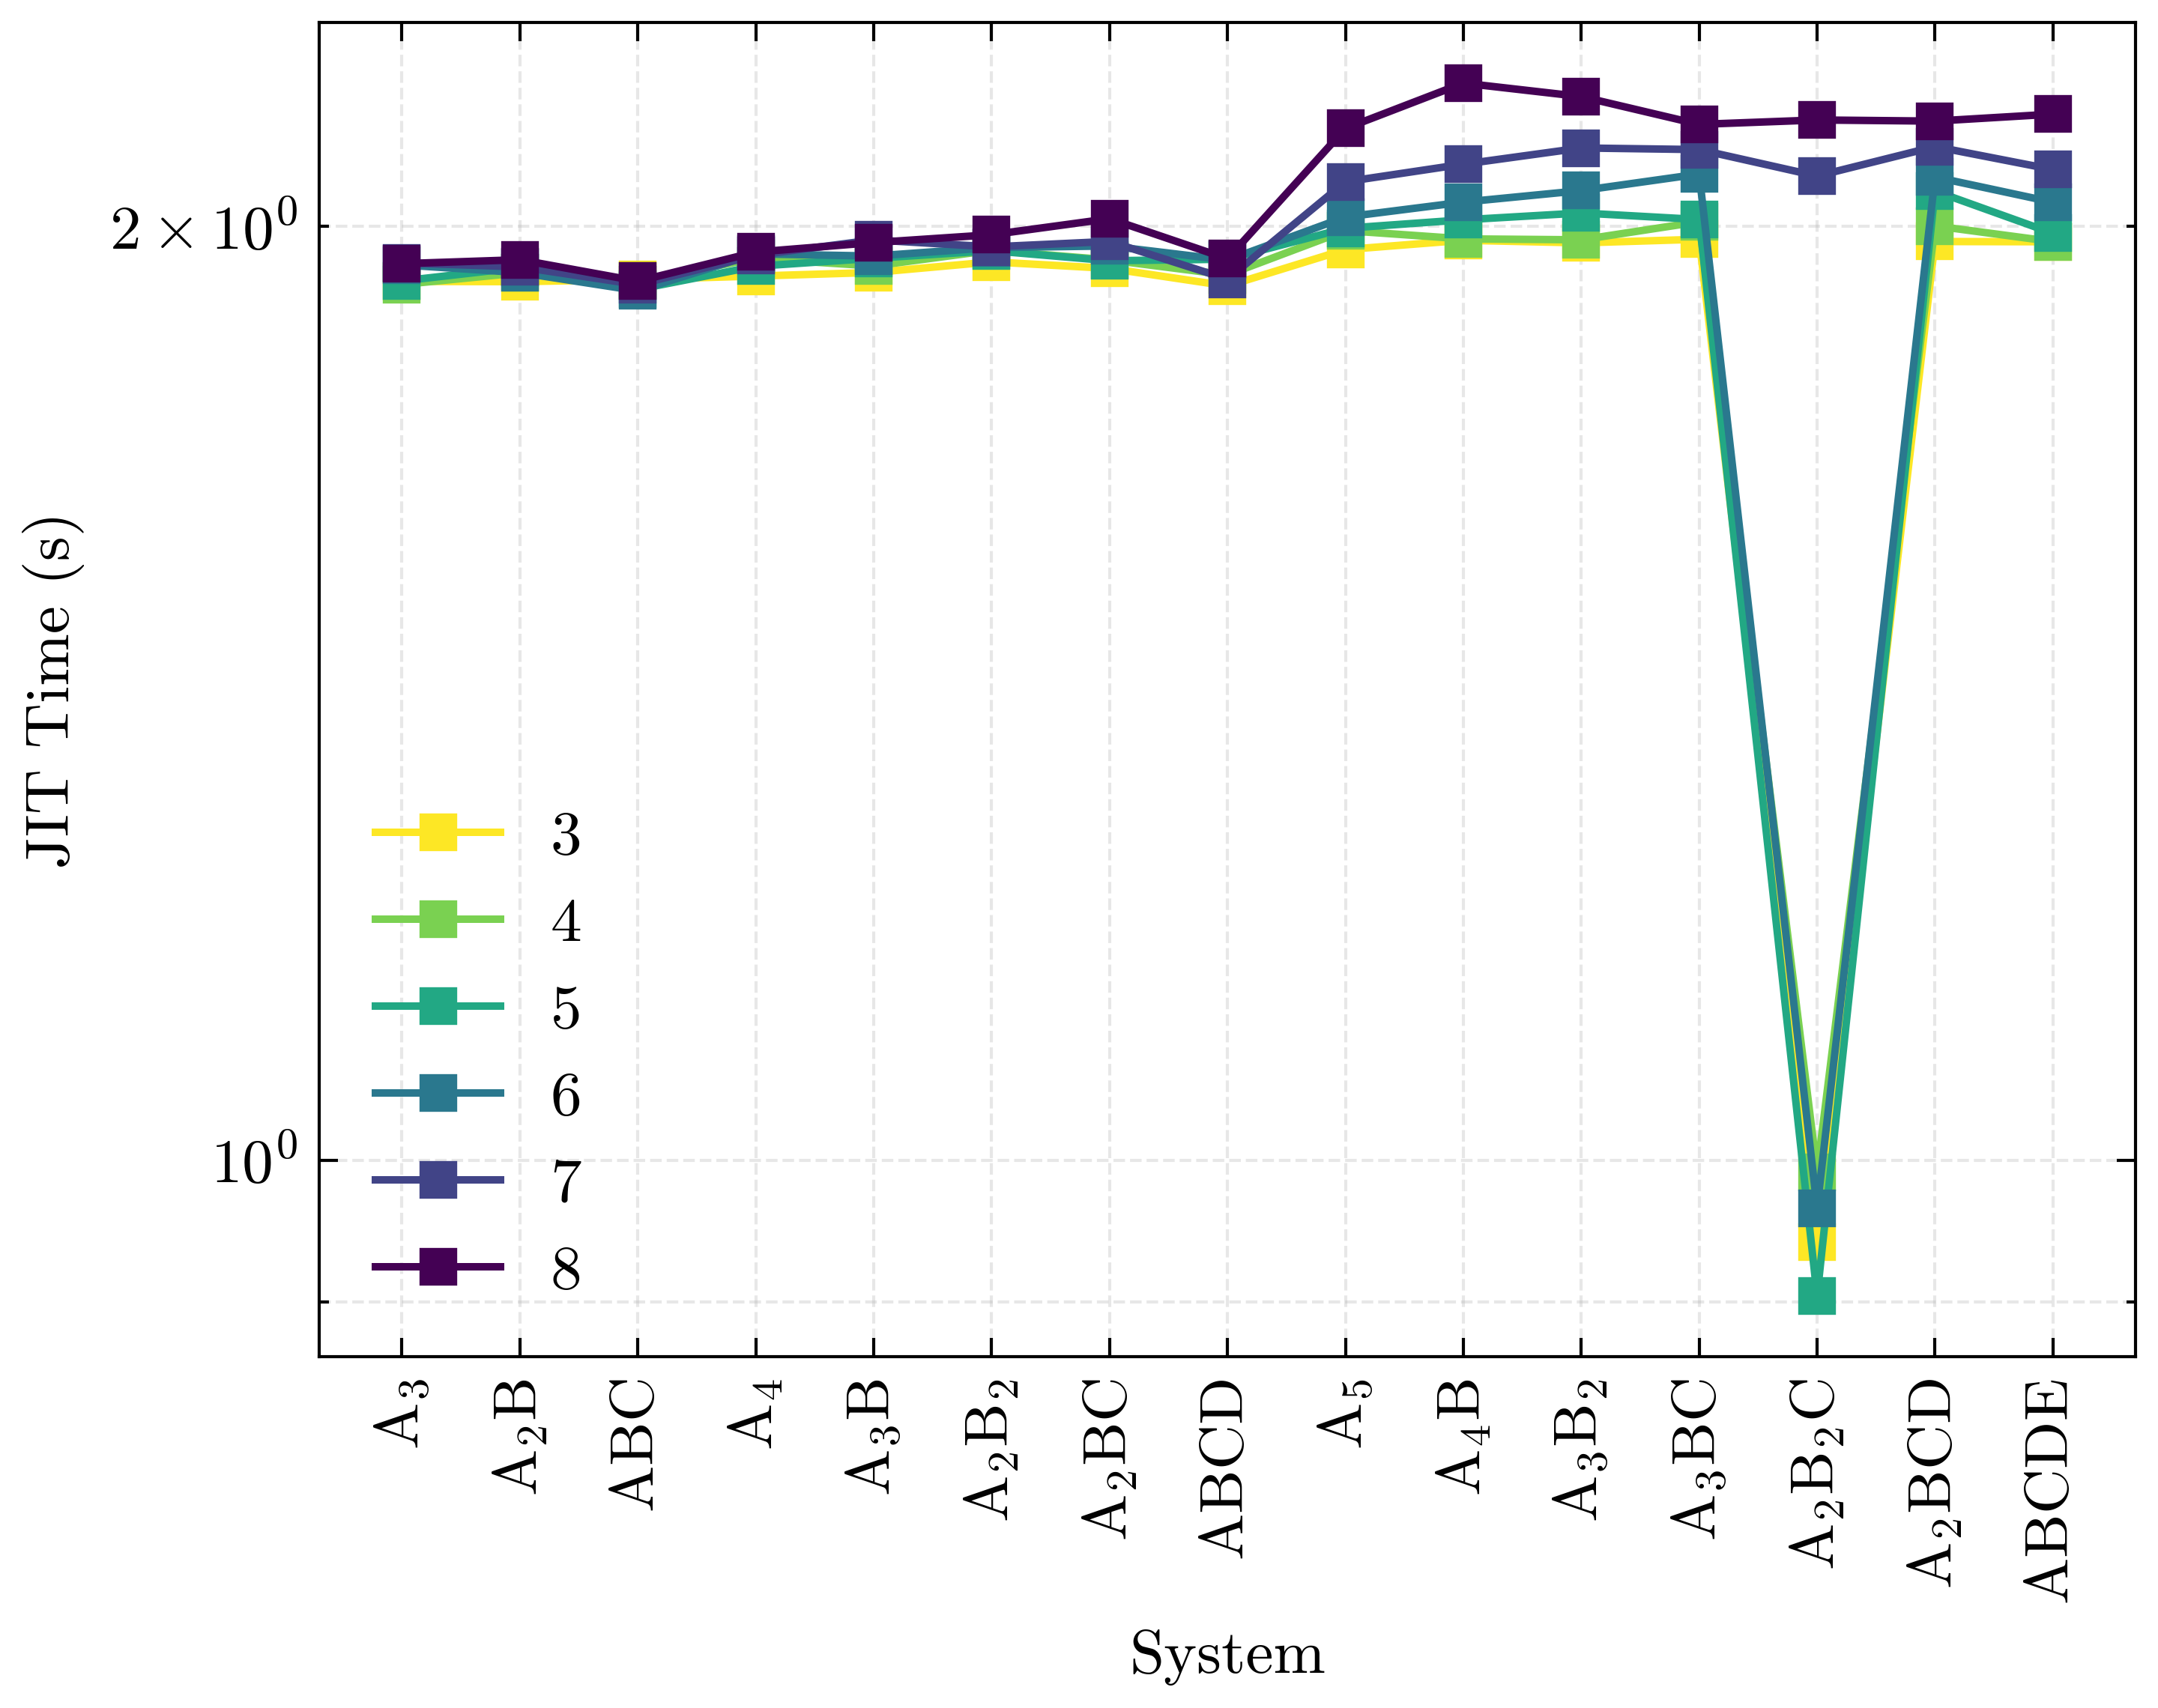

In [7]:
%matplotlib inline

plot_bench(df[df["batch_size"] == 1024], "jit")

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import re

import string


def plot_gpu_batch_scaling_mpl(
    df,
    target_systems,
):

    # 使用你提供的自定义排序函数
    sorted_systems = chemical_formula_sort(target_systems)
    
    plot_df = df[df["system"].isin(sorted_systems)].copy()
    # plot_df["run_per_sample_us"] = plot_df["run_per_sample"] * 1e6
    
    unique_orders = sorted(plot_df["order"].unique())
    # 使用 viridis_r 调色盘
    colors = plt.cm.viridis_r(np.linspace(0, 1, len(unique_orders)))

    # 2. 创建画布 (3行2列)
    with plt.style.context(["science", "no-latex"]):
        fig, axes = plt.subplots(
            nrows=4, ncols=2,
            figsize=(10, 12), 
            dpi=300, 
            constrained_layout=True
        )
        axes = axes.flatten()

        for i, system in enumerate(sorted_systems):
            ax = axes[i]
            sys_df = plot_df[plot_df["system"] == system]
            
            for j, order in enumerate(unique_orders):
                ord_df = sys_df[sys_df["order"] == order].sort_values("batch_size")
                
                if not ord_df.empty:
                    ax.plot(
                        ord_df["batch_size"], 
                        # ord_df["run_per_sample_us"], 
                        ord_df["run_per_sample"],
                        label=f"Order {order}",
                        color=colors[j],
                        marker='s',
                        markersize=4,
                        linewidth=1.5,
                        alpha=0.8,
                    )

            # 3. 坐标轴精细处理
            ax.set_xscale('log', base=2)
            ax.set_yscale('log')
            
            # 设置 X 轴刻度为 2 的幂次，并显示为整数
            batch_sizes = sorted(plot_df["batch_size"].unique())
            ax.set_xticks(batch_sizes)
            ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(
                lambda x, _: f'$2^{{{int(np.round(np.log2(x)))}}}$' if x > 0 else ""
            ))

            # 设置标题 (使用你的格式化函数)
            # ax.set_title(format_formula_for_matplotlib(system), fontsize=14)

            letter = string.ascii_lowercase[i]
            formatted_formula = format_formula_for_matplotlib(system)
            # 使用 loc='left' 是顶刊最常用的子图标记方式
            # ax.set_title(f"({letter}) {formatted_formula}", loc='right', fontsize=16, pad=10)

            ax.text(
                x=2**10,
                y=1.0e-04,
                s=f"({letter}) {formatted_formula}",
                fontsize=15,
            )

            ax.set_ylim([1.0e-08, 1.0e-03])

            # 只有最左列写 Y 轴标签
            if i % 2 == 0:
                ax.set_ylabel("Run Time per Sample (s)", fontsize=15)
            
            # 只有最下排写 X 轴标签
            if i >= 6:
                ax.set_xlabel("Batch Size", fontsize=15)

            if i == 0:
                ax.legend(
                    ncol=1,
                    frameon=False,
                    loc="lower left",
                )
            
            ax.grid(True, which="both", ls="--", alpha=0.3)

        plt.show()

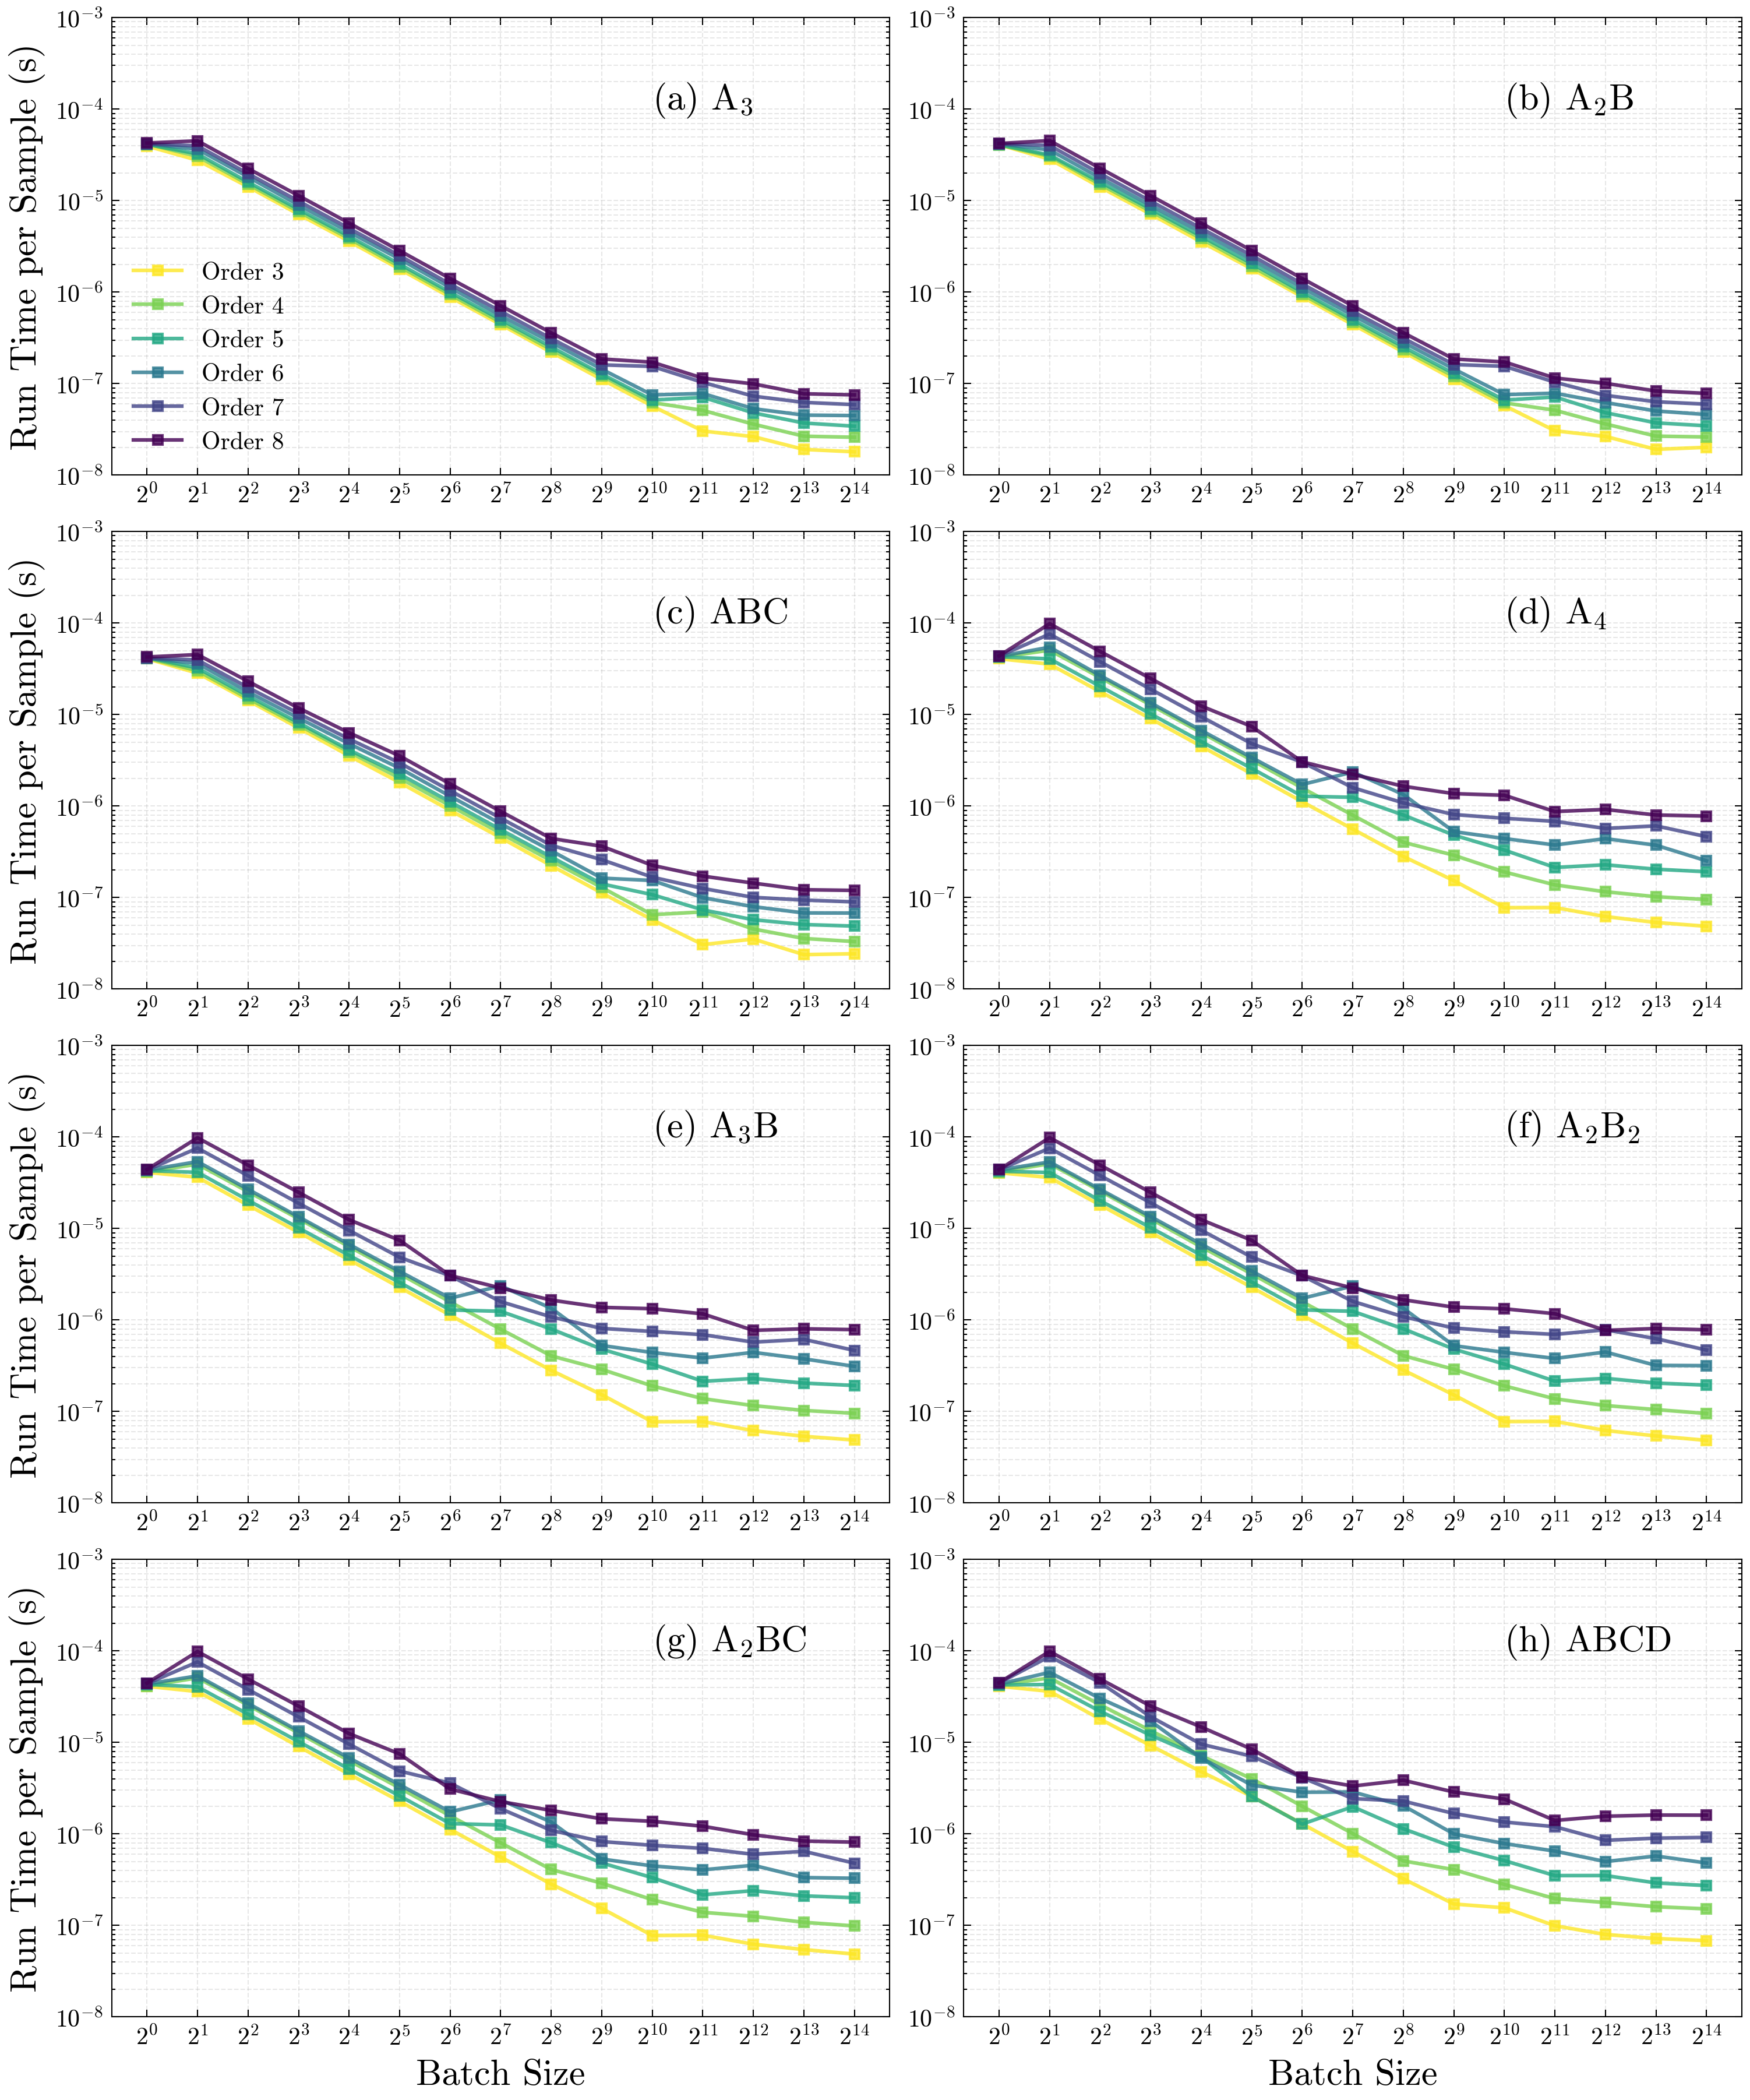

In [9]:
%matplotlib inline

plot_gpu_batch_scaling_mpl(
    df,
    target_systems=[
        "A3",
        "A2B",
        "ABC",
        "A4",
        "A3B",
        "A2B2",
        "A2BC",
        "ABCD",
        # "A5",
        # "A4B",
        # "A3BC",
        # "A2B2C",
        # "A2BCD",
        # "ABCDE",
    ]
)

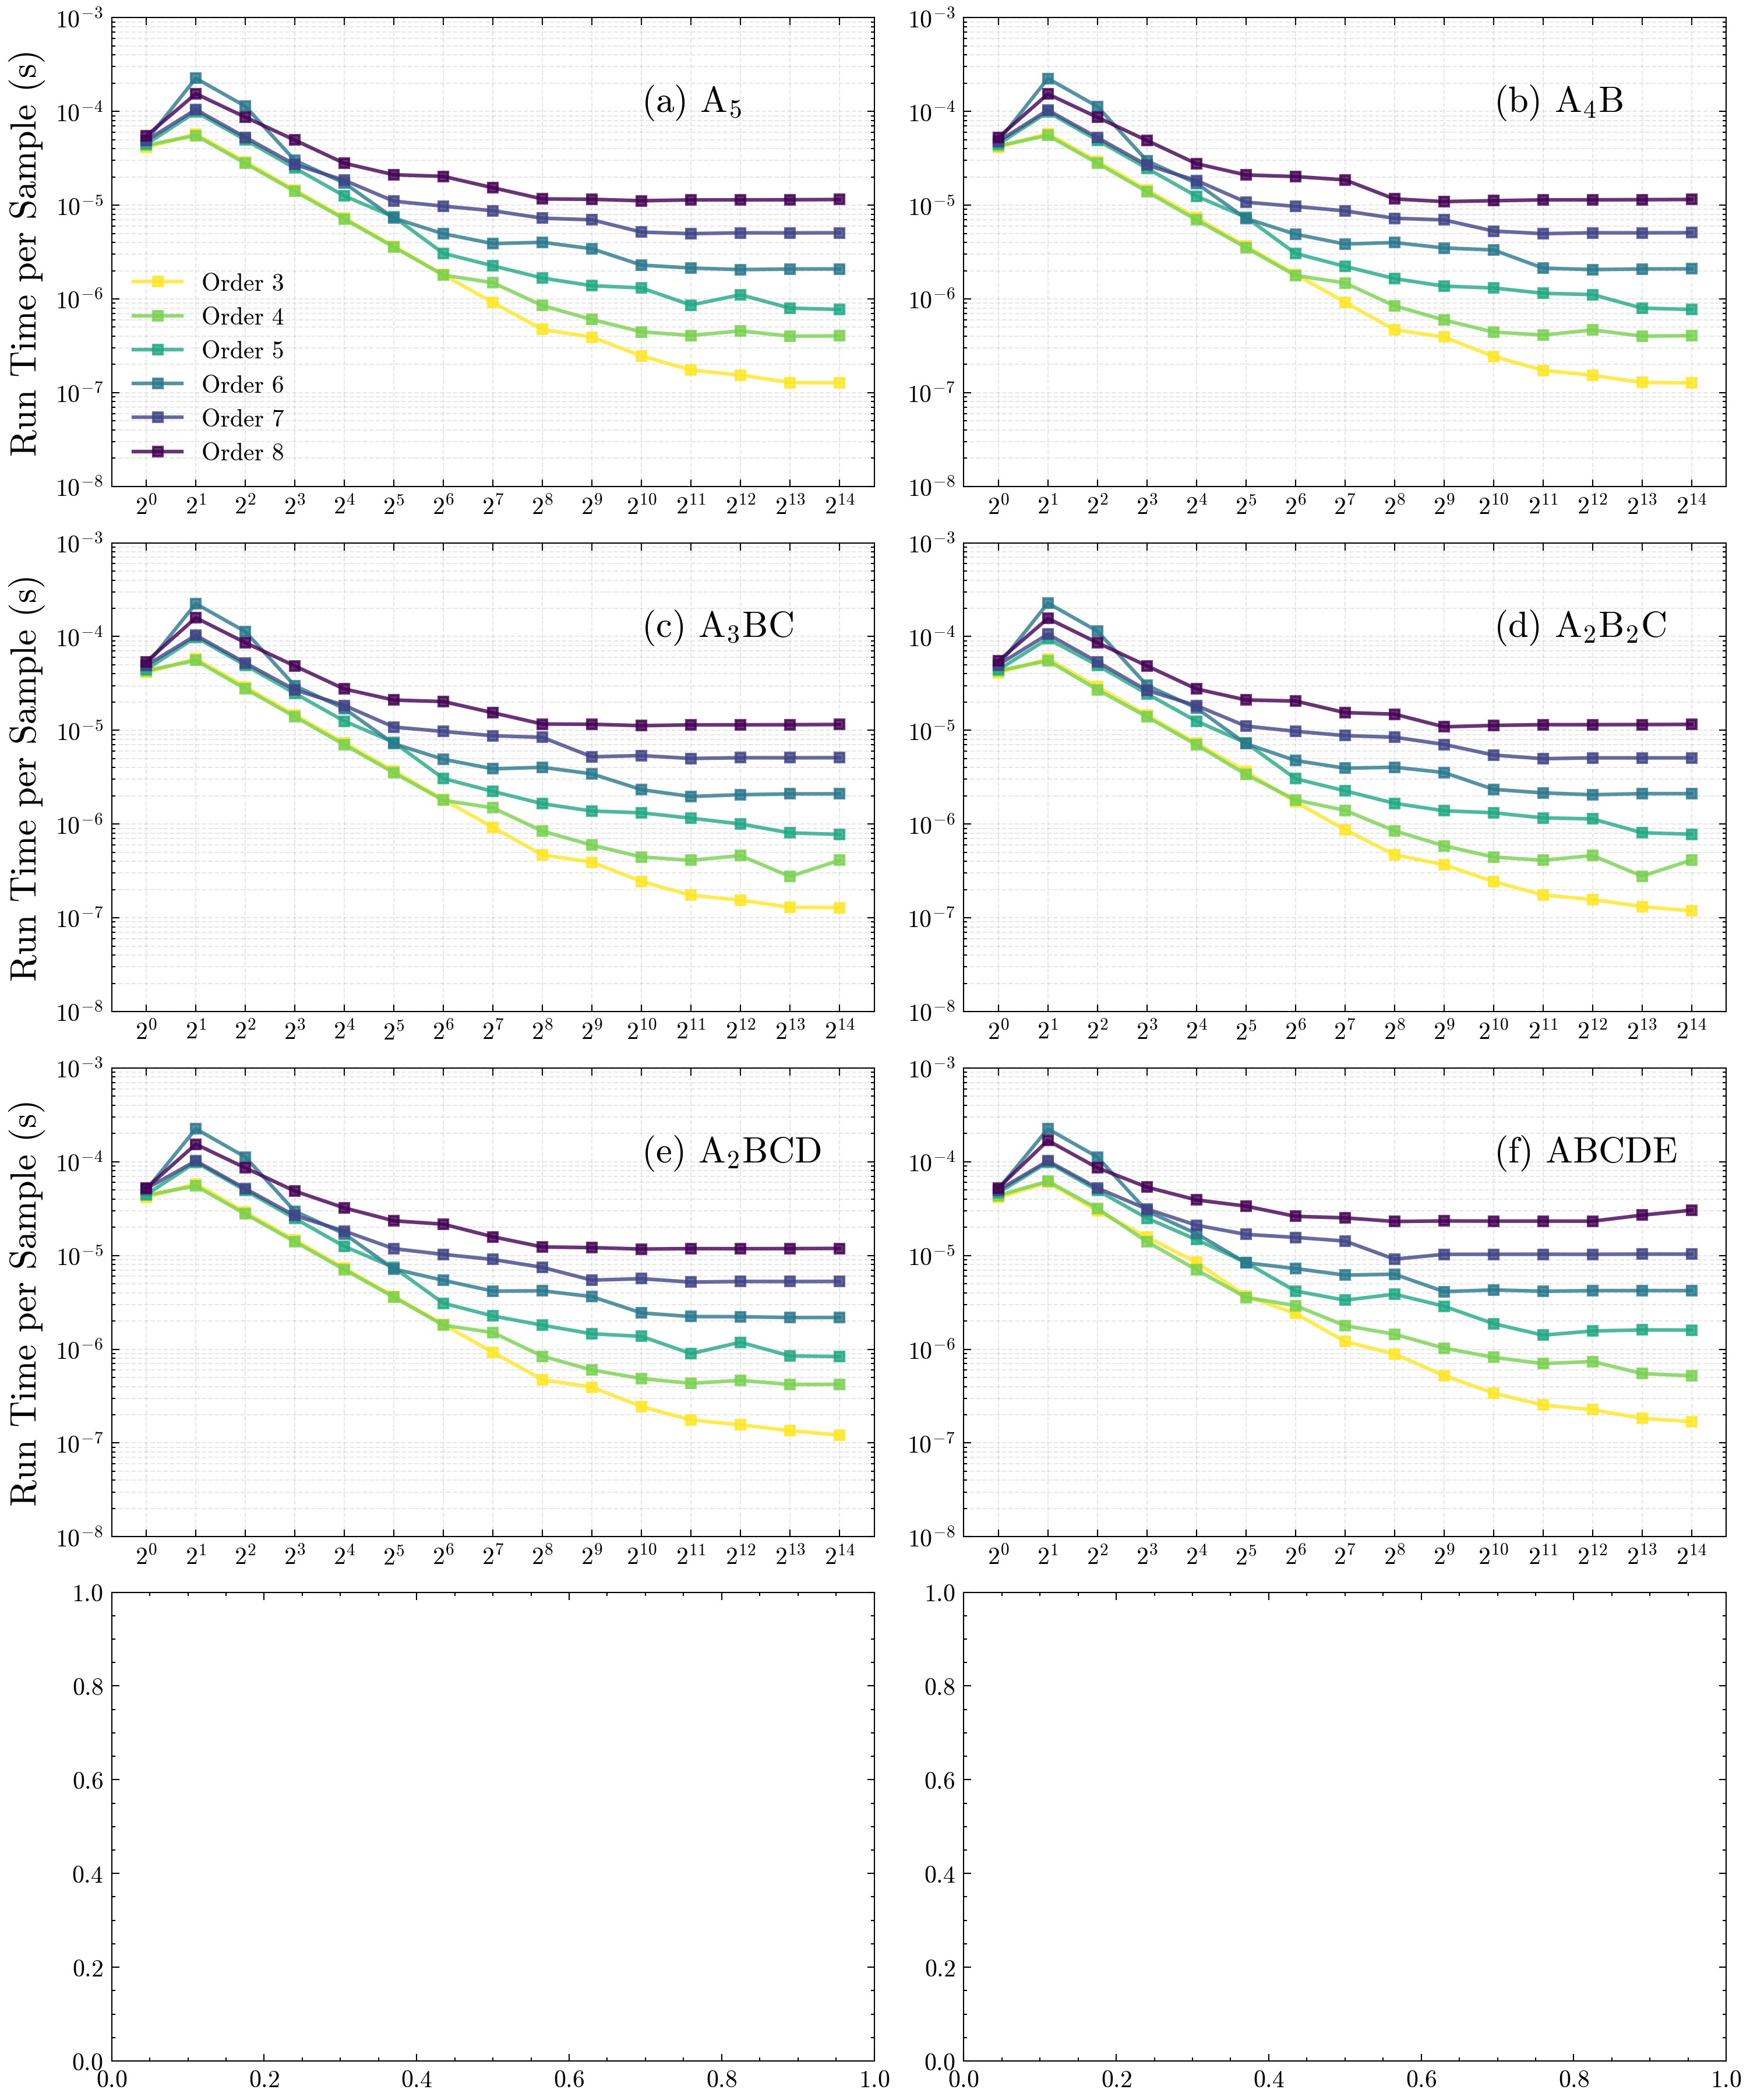

In [10]:
%matplotlib inline

plot_gpu_batch_scaling_mpl(
    df,
    target_systems=[
        # "A3",
        # "A2B",
        # "ABC",
        # "A4",
        # "A3B",
        # "A2B2",
        # "A2BC",
        # "ABCD",
        "A5",
        "A4B",
        "A3BC",
        "A2B2C",
        "A2BCD",
        "ABCDE",
    ]
)